In [ ]:
Build time series forecasting model using LSTM for AbbVie Inc ( Symbol: ABBV )
# Data file: 'prices_split_adjusted.csv'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [ ]:
df = pd.read_csv('/content/sample_data/prices_split_adjusted.csv')

# Clean symbol column
df['symbol'] = df['symbol'].str.strip().str.upper()

# Select ABT (Abbott Laboratories)
symbol = "ABT"
stock = df[df['symbol'] == symbol].copy()

print("Selected Symbol:", symbol)
print("Data Shape:", stock.shape)



Selected Symbol: ABT
Data Shape: (690, 7)


In [ ]:
data = stock[['close']].values

In [ ]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

In [ ]:
X = []
y = []
time_steps = 60

for i in range(time_steps, len(scaled_data)):
    X.append(scaled_data[i-time_steps:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

# reshape for LSTM
X = X.reshape(X.shape[0], X.shape[1], 1)


In [ ]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
y_train = y[:train_size]
X_test = X[train_size:]
y_test = y[train_size:]

In [ ]:
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)


Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 165ms/step - loss: 0.0358 - val_loss: 0.0687
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - loss: 0.0057 - val_loss: 0.0084
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0024 - val_loss: 0.0020
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0018 - val_loss: 0.0017
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0018 - val_loss: 0.0018
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0016 - val_loss: 0.0019
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0015 - val_loss: 0.0022
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0014 - val_loss: 0.0028
Epoch 9/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0013 - val_loss: 0.0018
Epoch 10/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0014 - val_loss: 0.0018
Epoch 11/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0012 - val_loss: 0.0018
Epoch 12/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step - loss: 

In [ ]:
predicted = model.predict(X_test)

predicted_prices = scaler.inverse_transform(predicted)
real_prices = scaler.inverse_transform(y_test.reshape(-1, 1))


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step


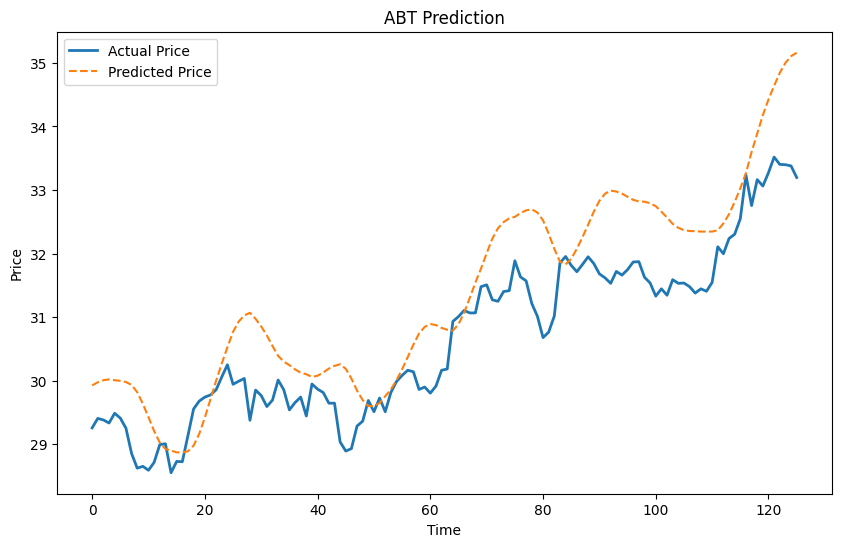

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(real_prices, label="Actual Price", linewidth=2)
plt.plot(predicted_prices, label="Predicted Price", linestyle='dashed')
plt.title(f"{symbol} Prediction")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()
